In [1]:
print('debug')

debug


In [ ]:
import gc
import json
import sys
import warnings
import os 
from pathlib import Path
from typing import Dict, Generator, List, Tuple
import numpy as np
import pandas as pd
import pyarrow as pa
import lightgbm as lgb
from pandas.api.types import CategoricalDtype
from pandas.api.types import CategoricalDtype
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import log_loss, accuracy_score
from scipy.stats import poisson, spearmanr
import warnings
import gc
import json
from ngboost import NGBRegressor
from ngboost.distns import Poisson as NGBPoisson
from ngboost.scores import LogScore, CRPScore
from lightgbmlss.model import LightGBMLSS
from lightgbmlss.distributions.Poisson import Poisson as LGBMLSSPoisson
from lightgbmlss.distributions.NegativeBinomial import NegativeBinomial
from typing import List, Union, Optional
from sklearn.base import BaseEstimator
from scipy.stats import nbinom, poisson

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ============================================================
# Configuration
# ============================================================
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# ============================================================
# Project paths
# ============================================================
NOTEBOOK = "corners"
PROJECT_ROOT = Path.cwd().parents[2]
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
CONFIG_PATH = PROJECT_ROOT / "configs" / f"{NOTEBOOK}"
# ============================================================
# Project modules
# ============================================================
from src.config.config import load_target_config

from src.utils.utils import (
      split_data,
      clean_key_missing,
      prepare_data_for_training,
      align_frame_to_reference,
      assert_same_categorical_schema,
      categorical_columns,
  )

from src.preprocessing.preprocessing import (
    corregir_marcadores_90,
    preprocessing_1x2_extra_time_filter,
    clean_dataset,
)

# Pipeline de distribucion
  # =============================================================================
from src.config.config import load_target_config

from src.metrics.distribution_metrics import (
    calculate_rps,
    calculate_nll,
    calculate_ece_by_threshold,
    evaluate_distribution_model,
    evaluate_from_config,
    total_pmf,
)

from src.training.distribution_models import (
    MODEL_NAMES,
    train_and_predict,
    predict_params,
    clip_params,
)

from src.training.distribution_cv import (
    build_component_data,
    compare_models,
    evaluate_on_validation,
    likelihood_ratio_test,
)

from src.hypertunning.distribution_tuning import run_tuning, tune_and_save

from src.evaluation.persistence import (
    save_evaluation,
    save_metrics,
    save_best_params,
    load_best_params,
)

from src.error_analysis.distribution_error_analysis import DistributionErrorAnalyzer

from src.utils.utils import save_feature_datasets
# ============================================================
# Experiment configuration
# ============================================================
TRAIN_MODE = True

COMP_TYPE = "clubs"

DATA_PATH = DATA_DIR / COMP_TYPE
RANDOM_STATE = 67
FEATURE_SELECTION_DIR = OUTPUTS_DIR / COMP_TYPE / "feature_selection_subset"
METRICS_DIR = OUTPUTS_DIR / COMP_TYPE / "model_metrics"
MODELS_DIR = OUTPUTS_DIR / COMP_TYPE / "models" / f"{NOTEBOOK}" 
SUBSET_DIR = OUTPUTS_DIR / COMP_TYPE / "feature_selection_subset" / f"{NOTEBOOK}"

SPLITS = {
    "train": ["2021/2022", "2022/2023", "2023/2024"],
    "val": ["2024/2025"],
    "test": ["2025/2026"],
}

# ============================================================
# Load data
# ============================================================
gc.collect()
df = pd.read_parquet(DATA_PATH / "club_features_dataset.parquet")

c:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
exclude_list = ["match_datetime_utc", "name", "match_id", "tournament"]

EXCLUDE_COLS, LEAKY_COLS, TARGET_COL = clean_dataset(df_cleaned, ["home_total_corners", "away_total_corners"])

df_ready = clean_key_missing(df_cleaned, cols_to_check = ["home_score", "away_score", "home_total_corners", "away_total_corners"])

df_train, df_val, df_test = split_data(
    df_ready,
    SPLITS
)

print(f"The shape of the TRAIN DATA IS: {df_train.shape}")
print(f"The shape of the VAL DATA IS: {df_val.shape}")
print(f"The shape of the TEST DATA IS: {df_test.shape}")


X_train, y_train, category_map = prepare_data_for_training(
    df_train,
    EXCLUDE_COLS,
    LEAKY_COLS,
    TARGET_COL,
)

X_val, y_val, _ = prepare_data_for_training(
    df_val,
    EXCLUDE_COLS,
    LEAKY_COLS,
    TARGET_COL,
    category_map=category_map,
)

X_test, y_test, _ = prepare_data_for_training(
    df_test,
    EXCLUDE_COLS,
    LEAKY_COLS,
    TARGET_COL,
    category_map=category_map,
)

print(f"The TRAIN SHAPE IS: {X_train.shape} & {y_train.shape}")
print(f"The VAL SHAPE IS: {X_val.shape} & {y_val.shape}")
print(f"The TEST SHAPE IS: {X_test.shape} & {y_test.shape}")


Removed 2333 rows with missing key odds.
Remaining rows: 11829
The shape of the TRAIN DATA IS: (7054, 1410)
The shape of the VAL DATA IS: (2248, 1410)
The shape of the TEST DATA IS: (2527, 1410)
The TRAIN SHAPE IS: (7054, 1048) & (7054, 2)
The VAL SHAPE IS: (2248, 1048) & (2248, 2)
The TEST SHAPE IS: (2527, 1048) & (2527, 2)


In [6]:
print(f'Mean home: {y_train["home_total_corners"].mean()} & variance {y_train["home_total_corners"].var()}')
print(f'Mean away: {y_train["away_total_corners"].mean()} & variance {y_train["away_total_corners"].var()}')
zero_home_ratio = (y_train["home_total_corners"] == 0).sum()
zero_away_ratio = (y_train["away_total_corners"] == 0).sum()
print(f'El tamaño de la muestra es de: {X_train.shape[0]}')
print(f'The zero ratio on home is: {zero_home_ratio/y_train.shape[0]:.4f} & The zero ratio Away is: {zero_away_ratio/y_train.shape[0]:.4f}')


Mean home: 5.354975900198469 & variance 8.752749233787473
Mean away: 4.264530762687837 & variance 6.714077073135474
El tamaño de la muestra es de: 7054
The zero ratio on home is: 0.0177 & The zero ratio Away is: 0.0383


In [7]:
from src.training.distribution_models import train_model
cfg = load_target_config("corners")

model_home = train_model(
    "LightGBMLSS", "poisson",
    X_train, y_train["home_total_corners"], X_val, y_val["home_total_corners"],
    params=cfg.model_params("LightGBMLSS"),
    fit_params=cfg.fit_params("LightGBMLSS"),
)

In [8]:
print("Training Away Corners Model...")
model_away = train_model(
    "LightGBMLSS", "poisson",
    X_train, y_train["away_total_corners"], X_val, y_val["away_total_corners"],
    params=cfg.model_params("LightGBMLSS"),
    fit_params=cfg.fit_params("LightGBMLSS"),
)

Training Away Corners Model...


### Baseline

In [9]:
from src.training.distribution_models import train_and_predict

model_home, params_home = train_and_predict(
    "LightGBMLSS", "poisson",
    X_train, y_train["home_total_corners"],
    X_val,   y_val["home_total_corners"],
    params=cfg.model_params("LightGBMLSS"),
    fit_params=cfg.fit_params("LightGBMLSS"),
    guards=cfg.numeric_guards,
)

model_away, params_away = train_and_predict(
    "LightGBMLSS", "poisson",
    X_train, y_train["away_total_corners"],
    X_val,   y_val["away_total_corners"],
    params=cfg.model_params("LightGBMLSS"),
    fit_params=cfg.fit_params("LightGBMLSS"),
    guards=cfg.numeric_guards,
)

from src.metrics.distribution_metrics import evaluate_from_config
from src.evaluation.persistence import save_evaluation

results = evaluate_from_config(
    y_true={
        "home": y_val["home_total_corners"].values,
        "away": y_val["away_total_corners"].values,
    },
    params={"home": params_home, "away": params_away},
    config=cfg,
    family="poisson",
    label="Baseline Poisson (LightGBMLSS)",
    verbose=True,
)

save_evaluation(
      results,
      name="baseline_poisson_validation_results",
      config=cfg,
      metadata={
          "models": {"home": "LightGBMLSS", "away": "LightGBMLSS"},
          "split": "validation",
          "n_features": {"home": X_train.shape[1],
                         "away": X_train.shape[1]},
      },
  )


  FULL EVALUATION - Baseline Poisson (LightGBMLSS) [poisson]

--------------------------------------------------
  RPS Report - Baseline Poisson (LightGBMLSS) | home [poisson]
--------------------------------------------------
  N observaciones : 2248
  RPS mean        : 1.54324   <- principal
  RPS std         : 1.28981
  RPS median      : 1.07168
  RPS p95         : 4.12033   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - Baseline Poisson (LightGBMLSS) | away [poisson]
--------------------------------------------------
  N observaciones : 2248
  RPS mean        : 1.39603   <- principal
  RPS std         : 1.23397
  RPS median      : 0.96285
  RPS p95         : 3.73051   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - Baseline Poisson (LightGBMLSS) | home [poisson]
--------------------------------------------------
  N observacio

WindowsPath('C:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/clubs/model_metrics/corners/baseline_poisson_validation_results.json')

### Feature selection Process

In [10]:
from src.config.config import load_config
from src.feature_selection.poisson_feature_selection import (
    PoissonSelectionConfig, run_poisson_feature_selection,
)

cfg = load_config(CONFIG_PATH / "corners_config.yaml")
sel_cfg = PoissonSelectionConfig.from_model_config(cfg)   # todo del YAML

home_final_features, Xtr_home, Xvl_home, Xte_home, report_home = run_poisson_feature_selection(
    X_train=X_train, X_val=X_val, X_test=X_test,
    y_train=y_train["home_total_corners"],
    y_val=y_val["home_total_corners"],
    target_name="home_total_corners",
    cfg=sel_cfg,
    max_k=cfg.target.max_k,
)


  [CHECK] El indice no es DatetimeIndex; no se puede verificar el
          orden cronologico automaticamente. Confirma a mano que
          X_train esta ordenado por fecha ASCENDENTE.
  POISSON TEMPORAL FEATURE SELECTION — target = home_total_corners
  Train: (7054, 1048)   Val: (2248, 1048)   Test: (2527, 1048)
  Target: media = 5.3550, var = 8.7515, var/media = 1.634
          >> Sobredispersion notable: considera Binomial Negativa
             para el modelo final. La seleccion sigue siendo valida.
  Ratio filas/features: 6.7:1
  Semilla: 67   Workers: 8

  STEP 0 — Sparsity Filter  (moda > 95%, NaN > 95%)
  Features entrada    : 1048
  Cuasi-constantes    : 37
  Features restantes  : 1011

  Categoricas declaradas: 57
  Esquema train/val/test: alineado y verificado.

  [AUDIT] 3 categoricas con niveles no vistos (>1%):
                     feature  n_levels_train  val_extra_nan_rate  test_extra_nan_rate
    home_roll_5_sp_goals_for              17              0.0004              

### Feature Selection Process END

In [11]:
home_final_features

['home_total_shots_elo_prob',
 'diff_roll_5_team_squad_value_eur',
 'diff_team_avg_crosses_last_5',
 'home_corners_elo_pre',
 'inter_elo_netcount',
 'diff_team_avg_possession_last_20',
 'away_team_avg_corners_against_last_20',
 'away_opponent_avg_crosses_last_20',
 'diff_team_avg_corners_last_20',
 'diff_team_avg_corners_against_last_20',
 'diff_global_form_points_last_5',
 'away_pct_team_scores_first_goal_last_20']

In [12]:
print(f"Inicio               : {report_home.n_start}")
print(f"Post Sparsity (S0)   : {report_home.n_after_sparsity}")
print(f"Post MI (S1)         : {report_home.n_after_mi}")        
print(f"Post Correlación (S2): {report_home.n_after_corr}")      
print(f"Post Permutación (S3): {report_home.n_after_shuffle}")   
print(f"Post Estabilidad (S4): {report_home.n_after_stability}")

Inicio               : 1048
Post Sparsity (S0)   : 1011
Post MI (S1)         : 365
Post Correlación (S2): 173
Post Permutación (S3): 13
Post Estabilidad (S4): 12


In [13]:
away_final_features, Xtr_away, Xvl_away, Xte_away, report_away = run_poisson_feature_selection(
    X_train=X_train, X_val=X_val, X_test=X_test,
    y_train=y_train["away_total_corners"],
    y_val=y_val["away_total_corners"],
    target_name="away_total_corners",
    cfg=CONFIG,
)

  [CHECK] El índice no es DatetimeIndex; no se puede verificar el
          orden cronológico automáticamente. Confirmá a mano que
          X_train está ordenado por fecha ASCENDENTE.
  POISSON TEMPORAL FEATURE SELECTION — target = away_total_corners
  Train: (7054, 1048)   Val: (2248, 1048)   Test: (2527, 1048)
  Target: media = 4.2645, var = 6.7131, var/media = 1.574
          >> Sobredispersión notable: considerá Binomial Negativa
             para el modelo final. La selección sigue siendo válida.
  Ratio filas/features: 6.7:1
  Semilla: 67   Workers: 8

  STEP 0 — Sparsity Filter  (moda > 95%, NaN > 95%)
  Features entrada    : 1048
  Cuasi-constantes    : 37
  Features restantes  : 1011

  Categóricas declaradas: 57

  [AUDIT] 3 categóricas con niveles no vistos (>1%):
                     feature  n_levels_train  val_extra_nan_rate  test_extra_nan_rate
    home_roll_5_sp_goals_for              17              0.0004               0.0305
home_roll_5_sp_goals_against             

In [14]:
away_final_features

['home_corners_elo_prob',
 'diff_net_counts',
 'diff_roll_5_team_squad_value_eur',
 'h2h_avg_total_corners_last_5',
 'diff_pct_team_scores_first_goal_last_20',
 'away_roll_5_team_squad_value_eur',
 'home_elo_rating_vs_league',
 'home_team_avg_goal_kicks_last_20',
 'home_team_avg_clearances_last_5',
 'home_opponent_avg_sot_last_20',
 'home_corners_elo_pre',
 'home_team_avg_corners_against_last_20',
 'diff_team_avg_conceded_last_20']

In [15]:
print(f"Inicio               : {report_away.n_start}")
print(f"Post Sparsity (S0)   : {report_away.n_after_sparsity}")
print(f"Post MI (S1)         : {report_away.n_after_mi}")        
print(f"Post Correlación (S2): {report_away.n_after_corr}")      
print(f"Post Permutación (S3): {report_away.n_after_shuffle}")   
print(f"Post Estabilidad (S4): {report_away.n_after_stability}")

Inicio               : 1048
Post Sparsity (S0)   : 1011
Post MI (S1)         : 333
Post Correlación (S2): 165
Post Permutación (S3): 15
Post Estabilidad (S4): 13


In [17]:
print(f"\nFeatures HOME: {home_final_features}")
print(f"Features AWAY: {away_final_features}")


Features HOME: ['home_total_shots_elo_prob', 'diff_roll_5_team_squad_value_eur', 'diff_team_avg_crosses_last_5', 'home_corners_elo_pre', 'inter_elo_netcount', 'diff_team_avg_possession_last_20', 'away_team_avg_corners_against_last_20', 'away_opponent_avg_crosses_last_20', 'diff_team_avg_corners_last_20', 'diff_team_avg_corners_against_last_20', 'diff_global_form_points_last_5', 'away_pct_team_scores_first_goal_last_20']
Features AWAY: ['home_corners_elo_prob', 'diff_net_counts', 'diff_roll_5_team_squad_value_eur', 'h2h_avg_total_corners_last_5', 'diff_pct_team_scores_first_goal_last_20', 'away_roll_5_team_squad_value_eur', 'home_elo_rating_vs_league', 'home_team_avg_goal_kicks_last_20', 'home_team_avg_clearances_last_5', 'home_opponent_avg_sot_last_20', 'home_corners_elo_pre', 'home_team_avg_corners_against_last_20', 'diff_team_avg_conceded_last_20']


In [18]:
from src.config.config import load_target_config
from src.training.distribution_cv import evaluate_on_validation
from src.evaluation.persistence import save_evaluation

cfg = load_target_config("corners")

X_tr = {"home": X_train, "away": X_train}
y_tr = {"home": y_train["home_total_corners"], "away": y_train["away_total_corners"]}
X_va = {"home": X_val,   "away": X_val}
y_va = {"home": y_val["home_total_corners"],   "away": y_val["away_total_corners"]}
feats = {"home": home_final_features, "away": away_final_features}

summary, results = evaluate_on_validation(
    cfg, X_tr, y_tr, X_va, y_va, feats,
    models=["LightGBMLSS"],
    family="poisson",
    verbose=True,
)

save_evaluation(
    results["LightGBMLSS"],
    "feature_selected_validation_baseline_results_corners",
    cfg,
    metadata={"split": "2024/2025", "label": "LightGBMLSS Baseline"},
)

--- Entrenando LightGBMLSS | home [poisson] ---
--- Entrenando LightGBMLSS | away [poisson] ---

  FULL EVALUATION - LightGBMLSS | poisson [poisson]

--------------------------------------------------
  RPS Report - LightGBMLSS | poisson | home [poisson]
--------------------------------------------------
  N observaciones : 2248
  RPS mean        : 1.57384   <- principal
  RPS std         : 1.26698
  RPS median      : 1.13320
  RPS p95         : 4.06894   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - LightGBMLSS | poisson | away [poisson]
--------------------------------------------------
  N observaciones : 2248
  RPS mean        : 1.38644   <- principal
  RPS std         : 1.20099
  RPS median      : 0.96339
  RPS p95         : 3.75054   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - LightGBMLSS | poisson | home [poisson]
-----

WindowsPath('C:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/clubs/model_metrics/goals/feature_selected_validation_baseline_results_corners.json')

In [2]:
import pandas as pd
from pathlib import Path
from typing import List

# Define the Metadata columns you want to keep
METADATA_COLS = [
    "match_datetime_utc",
    "match_id",
    "name",
    "home_total_corners",
    "away_total_corners",
    "tournament"
]

def prepare_and_save_datasets(
    df: pd.DataFrame,
    home_features: List[str],
    away_features: List[str],
    output_path: Path,
    home_name: str = "home_total_corners_feature_selection.parquet",
    away_name: str = "away_total_corners_feature_selection.parquet"
):
    print("--- Saving Final Datasets ---")

    df = df.copy()

    # Move the SAFETY FIX here to ensure RECENT_FORM_CHECK_IN receives a DataFrame with unique columns
    # 1. SAFETY FIX: Remove any duplicate columns that might have been created
    df = df.loc[:, ~df.columns.duplicated()].copy()


    # The line below was moved up to before RECENT_FORM_CHECK_IN
    # df = df.loc[:, ~df.columns.duplicated()].copy()

    # 2. Ensure Datetime format
    if not pd.api.types.is_datetime64_any_dtype(df["match_datetime_utc"]):
        df["match_datetime_utc"] = pd.to_datetime(df["match_datetime_utc"], format="ISO8601", errors="coerce")

    # NOTE: We removed the redundant feature engineering steps here
    # because your `df` already contains all the engineered features!

    print(f"Data Shape before saving: {df.shape}")

    # ==============================================================================
    # 3. SAVE HOME DATASET
    # ==============================================================================
    cols_to_save_home = METADATA_COLS + home_features
    cols_to_save_home = list(dict.fromkeys(cols_to_save_home)) # Remove duplicates

    valid_cols_home = [c for c in cols_to_save_home if c in df.columns]

    missing_home = set(cols_to_save_home) - set(valid_cols_home)
    if missing_home:
        print(f"\n[Home] Note: The following missing features were excluded from parquet: {missing_home}")

    df[valid_cols_home].to_parquet(output_path / home_name, index=False)
    print(f"Saved {home_name} with {len(valid_cols_home)} columns.")

    # ==============================================================================
    # 4. SAVE AWAY DATASET
    # ==============================================================================
    cols_to_save_away = METADATA_COLS + away_features
    cols_to_save_away = list(dict.fromkeys(cols_to_save_away))

    valid_cols_away = [c for c in cols_to_save_away if c in df.columns]

    missing_away = set(cols_to_save_away) - set(valid_cols_away)
    if missing_away:
        print(f"\n[Away] Note: The following missing features were excluded from parquet: {missing_away}")

    df[valid_cols_away].to_parquet(output_path / away_name, index=False)
    print(f"Saved {away_name} with {len(valid_cols_away)} columns.")

# Execute the save function
prepare_and_save_datasets(
    df=df_ready,
    home_features=home_final_features,
    away_features=away_final_features,
    output_path=SUBSET_DIR,
    home_name="home_total_corners_feature_selection.parquet",
    away_name="away_total_corners_feature_selection.parquet"
)

NameError: name 'df_ready' is not defined

### Model Creation

In [2]:
TARGET_COLS = ["home_total_corners", "away_total_corners"]

EXCLUDE_COLS = [
    'match_datetime_utc',
    'match_id',
    'name',
    'tournament'
]

LEAKY_COLS = ["home_total_corners", "away_total_corners"]

df_home = pd.read_parquet(SUBSET_DIR / 'home_total_corners_feature_selection.parquet')
df_away = pd.read_parquet(SUBSET_DIR / 'away_total_corners_feature_selection.parquet')

df_train_home, df_val_home, df_test_home = split_data(df_home, SPLITS)
df_train_away, df_val_away, df_test_away = split_data(df_away, SPLITS)

X_train_home, y_train_home, cat_features_home = prepare_data_for_training(df = df_train_home, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=None)
X_val_home, y_val_home, _ = prepare_data_for_training(df = df_val_home, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=cat_features_home)
X_test_home, y_test_home, _ = prepare_data_for_training(df = df_test_home, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=cat_features_home)
print('HOME INFO')
print(f'The TRAIN SHAPE IS: {X_train_home.shape} & {y_train_home.shape}')
print(f'The VAL SHAPE IS: {X_val_home.shape} & {y_val_home.shape}')
print(f'The TEST SHAPE IS: {X_test_home.shape} & {y_test_home.shape}')

print('AWAY INFO')
X_train_away, y_train_away, cat_features_away = prepare_data_for_training(df = df_train_away, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=None)
X_val_away, y_val_away, _ = prepare_data_for_training(df = df_val_away, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=cat_features_away)
X_test_away, y_test_away, _ = prepare_data_for_training(df = df_test_away, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=cat_features_away)
print(f'The TRAIN SHAPE IS: {X_train_away.shape} & {y_train_away.shape}')
print(f'The VAL SHAPE IS: {X_val_away.shape} & {y_val_away.shape}')
print(f'The TEST SHAPE IS: {X_test_away.shape} & {y_test_away.shape}')

HOME INFO
The TRAIN SHAPE IS: (7054, 12) & (7054, 2)
The VAL SHAPE IS: (2248, 12) & (2248, 2)
The TEST SHAPE IS: (2527, 12) & (2527, 2)
AWAY INFO
The TRAIN SHAPE IS: (7054, 13) & (7054, 2)
The VAL SHAPE IS: (2248, 13) & (2248, 2)
The TEST SHAPE IS: (2527, 13) & (2527, 2)


In [22]:
from src.config.config import load_target_config
from src.training.distribution_cv import compare_models
from src.evaluation.persistence import save_metrics

cfg = load_target_config("goals")

X     = {"home": X_train_home, "away": X_train_away}
y     = {"home": y_train_home["home_total_corners"], "away": y_train_away["away_total_corners"]}
feats = {"home": X_train_home.columns.tolist(), "away": X_train_away.columns.tolist()}

comparison = compare_models(cfg, X, y, feats)   # 3 modelos x 2 familias x 2 componentes

print(comparison["summary"].to_string(index=False))
print(comparison["lr_tests"].to_string(index=False))

save_metrics(
    {
        "summary":   comparison["summary"],
        "lr_tests":  comparison["lr_tests"],
        "failures":  comparison["failures"],
    },
    "model_selection_results_validation",
    cfg,
)


  [LightGBMLSS | poisson] TSCV (n_splits=5)...
    Fold 1 - RPS: 4.32970 | NLL: 10.33668
    Fold 2 - RPS: 1.31250 | NLL: 2.36316
    Fold 3 - RPS: 1.34697 | NLL: 2.45887
    Fold 4 - RPS: 1.38175 | NLL: 2.49335
    Fold 5 - RPS: 1.36626 | NLL: 2.48494

  [LightGBMLSS | negbin] TSCV (n_splits=5)...
    Fold 1 - RPS: 4.60622 | NLL: 6.80340
    Fold 2 - RPS: 4.47771 | NLL: 6.61876
    Fold 3 - RPS: 1.62957 | NLL: 2.60486
    Fold 4 - RPS: 1.82665 | NLL: 2.75989
    Fold 5 - RPS: 1.69922 | NLL: 2.66045

  [XGBoostLSS | poisson] TSCV (n_splits=5)...
    Fold 1 - RPS: 1.32960 | NLL: 2.41626
    Fold 2 - RPS: 1.31907 | NLL: 2.36862
    Fold 3 - RPS: 1.34461 | NLL: 2.45702
    Fold 4 - RPS: 1.38186 | NLL: 2.49392
    Fold 5 - RPS: 1.36184 | NLL: 2.48069

  [XGBoostLSS | negbin] TSCV (n_splits=5)...
    Fold 1 - RPS: 1.59829 | NLL: 2.59441
    Fold 2 - RPS: 1.55617 | NLL: 2.51918
    Fold 3 - RPS: 1.57678 | NLL: 2.56399
    Fold 4 - RPS: 1.82913 | NLL: 2.76010
    Fold 5 - RPS: 1.65812 | NLL:

WindowsPath('C:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/clubs/model_metrics/goals/model_selection_results_validation.json')

In [23]:
runs = {}

X_tr  = {"home": X_train_home, "away": X_train_away}
y_tr  = {"home": y_train_home["home_total_corners"], "away": y_train_away["away_total_corners"]}
X_va  = {"home": X_val_home,   "away": X_val_away}
y_va  = {"home": y_val_home["home_total_corners"],   "away": y_val_away["away_total_corners"]}
feats = {"home": X_train_home.columns.to_list(), "away": X_train_away.columns.to_list()}

for fam in cfg.distributions:          # ["poisson", "negbin"]
    summary, results = evaluate_on_validation(
        cfg, X_tr, y_tr, X_va, y_va, feats,
        family=fam,
        verbose=False,
    )
    runs[fam] = summary.assign(family=fam)

save_metrics(pd.concat(runs.values(), ignore_index=True),
            "validation_results_by_model_corners", cfg)

 [METRICS] validation_results_by_model_corners -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\goals\validation_results_by_model_corners.json


WindowsPath('C:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/clubs/model_metrics/goals/validation_results_by_model_corners.json')

### Hypertunning

In [24]:
from src.config.config import load_target_config
from src.hypertunning.distribution_tuning import tune_and_save

cfg = load_target_config("corners")

tuning_poisson_home_ng = tune_and_save(
    model_name    = "NGBoost",
    family        = "poisson",              # o "negbin", segun el LR test
    X_train       = X_train_home,
    y_train       = y_train_home["home_total_corners"],
    features      = X_train_home.columns.to_list(),
    config        = cfg,
    component_key = "home",
    n_trials      = 100,
    n_splits      = 5,
)


  OPTUNA TUNING - NGBoost | poisson | home
  Metrica objetivo : nll (menor es mejor)
  Trials : 100 | TSCV folds : 5
  Features : 12


Best trial: 99. Best value: 2.43525: 100%|██████████| 100/100 [33:37<00:00, 20.17s/it]


  Best nll      : 2.43525
  Completed trials : 99
  Pruned trials    : 1
  Best params:
    max_depth             : 2
    min_samples_leaf      : 48
    n_estimators          : 1300
    learning_rate         : 0.005027051967689165
    col_sample            : 0.506177349810166
 [CONFIG] best_params_ngboost_poisson_home -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\configs\goals\best_params_ngboost_poisson_home.yaml
 [METRICS] tuning_ngboost_poisson_home -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\goals\tuning_ngboost_poisson_home.json


In [25]:
cfg = load_target_config("corners")

tuning_poisson_away_ng = tune_and_save(
    model_name    = "NGBoost",
    family        = "poisson",              # o "negbin", segun el LR test
    X_train       = X_train_away,
    y_train       = y_train_away["away_total_corners"],
    features      = X_train_away.columns.to_list(),
    config        = cfg,
    component_key = "away",
    n_trials      = 100,
    n_splits      = 5,
)


  OPTUNA TUNING - NGBoost | poisson | away
  Metrica objetivo : nll (menor es mejor)
  Trials : 100 | TSCV folds : 5
  Features : 13


Best trial: 85. Best value: 2.27252: 100%|██████████| 100/100 [37:25<00:00, 22.46s/it]


  Best nll      : 2.27252
  Completed trials : 60
  Pruned trials    : 40
  Best params:
    max_depth             : 3
    min_samples_leaf      : 38
    n_estimators          : 1800
    learning_rate         : 0.00603685330378589
    col_sample            : 0.505383317909306
 [CONFIG] best_params_ngboost_poisson_away -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\configs\goals\best_params_ngboost_poisson_away.yaml
 [METRICS] tuning_ngboost_poisson_away -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\goals\tuning_ngboost_poisson_away.json


In [26]:
from pathlib import Path
from src.config.config import load_target_config
from src.training.distribution_cv import evaluate_on_validation
from src.evaluation.persistence import save_evaluation

cfg = load_target_config("corners")

X_tr  = {"home": X_train_home, "away": X_train_away}
y_tr  = {"home": y_train_home["home_total_corners"], "away": y_train_away["away_total_corners"]}
X_va  = {"home": X_val_home,   "away": X_val_away}
y_va  = {"home": y_val_home["home_total_corners"],   "away": y_val_away["away_total_corners"]}
feats = {"home": home_final_features, "away": away_final_features}

# Cada componente con los hiperparametros que gano SU tuning
best = {"NGBoost": {
    "home": tuning_poisson_home_ng["best_params"],
    "away": tuning_poisson_away_ng["best_params"],
}}

summary, results = evaluate_on_validation(
    cfg, X_tr, y_tr, X_va, y_va, feats,
    models      = ["NGBoost"],
    family      = "poisson",
    best_params = best,
)

print(summary.to_string(index=False))

MODEL_DIR = OUTPUTS_DIR / "models" / "corners"

save_evaluation(
    results["NGBoost"],
    "hypertunned_ngboost_validation_results",
    cfg,
    metadata    = {"label": "NGBoost_Tuned_Poisson", "stage": "feature_selection_subset"},
    metrics_dir = MODEL_DIR,
)

--- Entrenando NGBoost | home [poisson] ---
--- Entrenando NGBoost | away [poisson] ---

  FULL EVALUATION - NGBoost | poisson [poisson]

--------------------------------------------------
  RPS Report - NGBoost | poisson | home [poisson]
--------------------------------------------------
  N observaciones : 2248
  RPS mean        : 1.57724   <- principal
  RPS std         : 1.26470
  RPS median      : 1.13471
  RPS p95         : 4.02847   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - NGBoost | poisson | away [poisson]
--------------------------------------------------
  N observaciones : 2248
  RPS mean        : 1.38621   <- principal
  RPS std         : 1.18510
  RPS median      : 0.98695
  RPS p95         : 3.66939   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - NGBoost | poisson | home [poisson]
-----------------------------

WindowsPath('c:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/models/corners/hypertunned_ngboost_validation_results.json')

In [27]:
from src.config.config import load_target_config
from src.hypertunning.distribution_tuning import tune_and_save

cfg = load_target_config("corners")

tuning_home_ng = tune_and_save(
    model_name    = "NGBoost",
    family        = "negbin",              # o "negbin", segun el LR test
    X_train       = X_train_home,
    y_train       = y_train_home["home_total_corners"],
    features      = X_train_home.columns.to_list(),
    config        = cfg,
    component_key = "home",
    n_trials      = 100,
    n_splits      = 5,
)


  OPTUNA TUNING - NGBoost | negbin | home
  Metrica objetivo : nll (menor es mejor)
  Trials : 100 | TSCV folds : 5
  Features : 12


Best trial: 66. Best value: 2.39723: 100%|██████████| 100/100 [59:03<00:00, 35.44s/it]


  Best nll      : 2.39723
  Completed trials : 97
  Pruned trials    : 3
  Best params:
    max_depth             : 2
    min_samples_leaf      : 49
    n_estimators          : 750
    learning_rate         : 0.00507162744910221
    col_sample            : 0.6562075014157249
 [CONFIG] best_params_ngboost_negbin_home -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\configs\goals\best_params_ngboost_negbin_home.yaml
 [METRICS] tuning_ngboost_negbin_home -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\goals\tuning_ngboost_negbin_home.json


In [28]:
tuning_away_ng = tune_and_save(
    model_name    = "NGBoost",
    family        = "negbin",              # o "negbin", segun el LR test
    X_train       = X_train_away,
    y_train       = y_train_away["away_total_corners"],
    features      = X_train_away.columns.to_list(),
    config        = cfg,
    component_key = "away",
    n_trials      = 100,
    n_splits      = 5,
)


  OPTUNA TUNING - NGBoost | negbin | away
  Metrica objetivo : nll (menor es mejor)
  Trials : 100 | TSCV folds : 5
  Features : 13


Best trial: 73. Best value: 2.24434: 100%|██████████| 100/100 [1:11:49<00:00, 43.10s/it]


  Best nll      : 2.24434
  Completed trials : 75
  Pruned trials    : 25
  Best params:
    max_depth             : 3
    min_samples_leaf      : 50
    n_estimators          : 1150
    learning_rate         : 0.005014753396902601
    col_sample            : 0.5219971421177583
 [CONFIG] best_params_ngboost_negbin_away -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\configs\goals\best_params_ngboost_negbin_away.yaml
 [METRICS] tuning_ngboost_negbin_away -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\goals\tuning_ngboost_negbin_away.json


In [29]:
best_nb = {"NGBoost": {
      "home": tuning_home_ng["best_params"],
      "away": tuning_away_ng["best_params"],
  }}

summary_nb, results_nb = evaluate_on_validation(
    cfg, X_tr, y_tr, X_va, y_va, feats,
    models      = ["NGBoost"],
    family      = "negbin",
    best_params = best_nb,
)

print(summary_nb.to_string(index=False))

save_evaluation(
    results_nb["NGBoost"],
    "hypertunned_ngboost_negbin_validation_results",
    cfg,
    metadata    = {"label": "NGBoost_NegBin_Tuned"},
    metrics_dir = MODEL_DIR,
)

comparison = pd.concat([
    summary.assign(tuned_for="poisson"),
    summary_nb.assign(tuned_for="negbin"),
], ignore_index=True)
print(comparison.to_string(index=False))

--- Entrenando NGBoost | home [negbin] ---
--- Entrenando NGBoost | away [negbin] ---

  FULL EVALUATION - NGBoost | negbin [negbin]

--------------------------------------------------
  RPS Report - NGBoost | negbin | home [negbin]
--------------------------------------------------
  N observaciones : 2248
  RPS mean        : 1.55911   <- principal
  RPS std         : 1.13591
  RPS median      : 1.14570
  RPS p95         : 3.79660   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - NGBoost | negbin | away [negbin]
--------------------------------------------------
  N observaciones : 2248
  RPS mean        : 1.37222   <- principal
  RPS std         : 1.07847
  RPS median      : 0.99334
  RPS p95         : 3.42456   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - NGBoost | negbin | home [negbin]
---------------------------------------

### XGBLSS

In [30]:
from src.config.config import load_target_config
from src.hypertunning.distribution_tuning import tune_and_save

cfg = load_target_config("corners")

tuning_home_ng = tune_and_save(
    model_name    = "XGBoostLSS",
    family        = "negbin",              # o "negbin", segun el LR test
    X_train       = X_train_home,
    y_train       = y_train_home["home_total_corners"],
    features      = X_train_home.columns.to_list(),
    config        = cfg,
    component_key = "home",
    n_trials      = 100,
    n_splits      = 5,
)


  OPTUNA TUNING - XGBoostLSS | negbin | home
  Metrica objetivo : nll (menor es mejor)
  Trials : 100 | TSCV folds : 5
  Features : 12


Best trial: 89. Best value: 2.54584: 100%|██████████| 100/100 [1:35:54<00:00, 57.54s/it]


  Best nll      : 2.54584
  Completed trials : 68
  Pruned trials    : 32
  Best params:
    learning_rate         : 0.02879983315311574
    max_depth             : 3
    min_child_weight      : 24
    colsample_bytree      : 0.8370499447912969
    subsample             : 0.9375097007949728
 [CONFIG] best_params_xgboostlss_negbin_home -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\configs\goals\best_params_xgboostlss_negbin_home.yaml
 [METRICS] tuning_xgboostlss_negbin_home -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\goals\tuning_xgboostlss_negbin_home.json


### Error Analysis


  NGBoost_NegBin_Tuned [negbin] - HOME | N=2,248
  RPS mean=1.07956  |  media predicha=5.4536

------------------------------------------------------------
  [1] Calibracion - NGBoost_NegBin_Tuned | HOME
------------------------------------------------------------
   pred_bin   n  pred_mean  ytrue_mean  rps_mean
 [2.5, 3.5)  44   3.360988    2.886364  0.927681
 [3.5, 4.5) 342   4.065227    3.836257  1.150891
 [4.5, 5.5) 928   5.027108    4.894397  1.161459
 [5.5, 6.5) 501   5.939927    5.710579  1.056243
 [6.5, 7.5) 344   6.901910    6.816860  0.942801
 [7.5, 8.5)  81   7.840832    7.604938  0.738625
 [8.5, 9.5)   7   8.740402    9.428571  0.167898
[9.5, 10.5)   1   9.934744    9.000000  0.078662


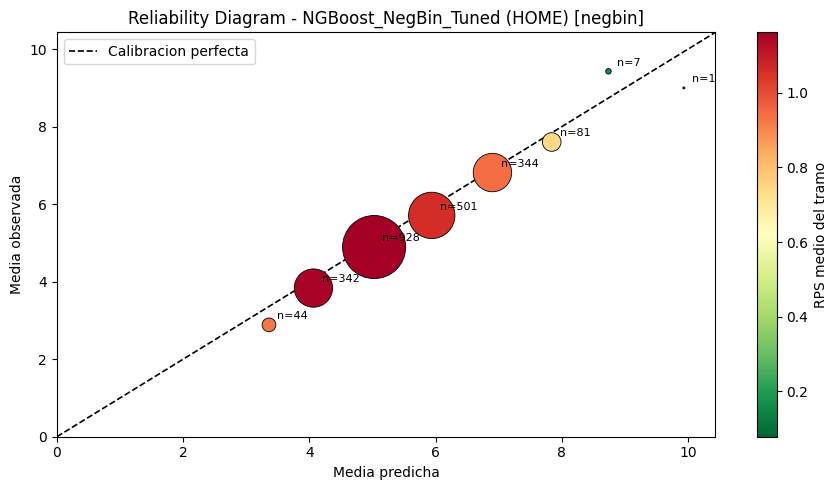


------------------------------------------------------------
  [2] Residuos por y_true - NGBoost_NegBin_Tuned | HOME
------------------------------------------------------------
y_true   n  residual_mean  ci_low  ci_high
     0  57        -4.8395 -5.0543  -4.6330
     1 123        -3.9275 -4.0950  -3.7535
     2 220        -2.9281 -3.0502  -2.8100
     3 285        -2.1843 -2.2962  -2.0685
     4 339        -1.3241 -1.4256  -1.2232
     5 283        -0.4321 -0.5519  -0.3163
    6+ 941         2.3539  2.2143   2.5000


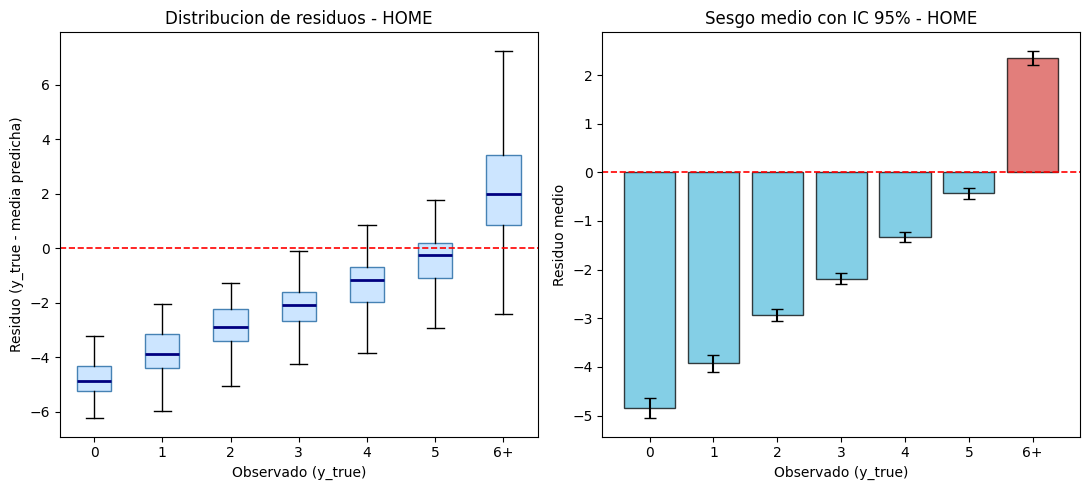


------------------------------------------------------------
  [3] Cola RPS > p95 - NGBoost_NegBin_Tuned | HOME
------------------------------------------------------------
  Umbral RPS p95 : 2.51849
  En la cola          : 113 (5.0%)

grupo    n  rps_mean  ytrue_mean  pred_mean  residual_mean
 cola  113    3.1612      0.7611     5.6596        -4.8985
resto 2135    0.9694      5.5232     5.4427         0.0805


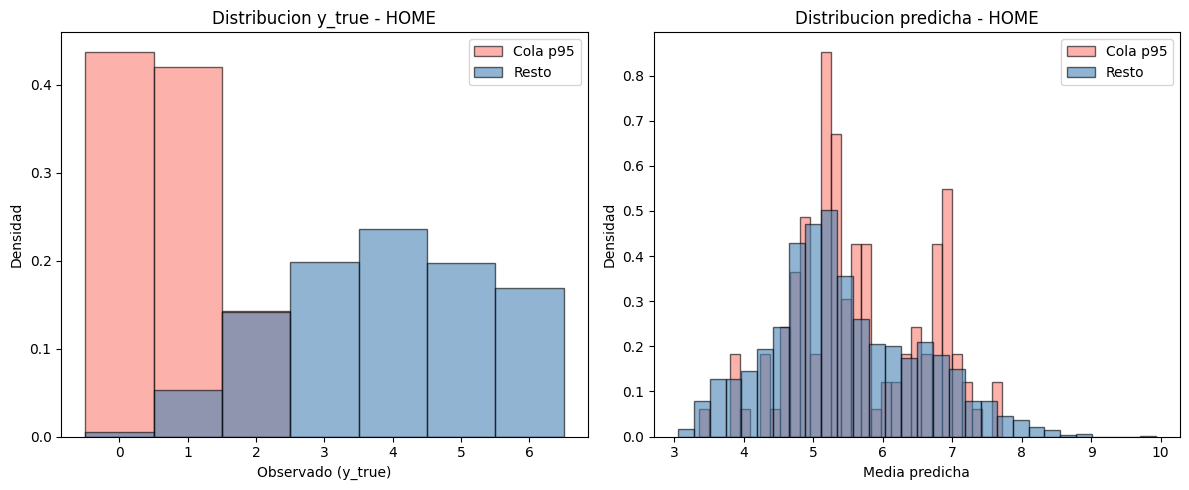


------------------------------------------------------------
  [4] Sesgo por 'tournament' - NGBoost_NegBin_Tuned | HOME
------------------------------------------------------------
           tournament   n  rps_mean  residual_mean  ytrue_mean  pred_mean
      coupe_de_france  52  1.966341      -1.994155    3.384615   5.378770
              serie-a 395  1.107986      -0.121211    5.240506   5.361718
              ligue-1 310  1.098774      -0.488383    4.951613   5.439995
   uefa-europa-league 169  1.094304       0.064911    5.520710   5.455799
       premier-league 360  1.060261      -0.189492    5.325000   5.514492
               laliga 409  1.036385      -0.117019    5.366748   5.483767
uefa-champions-league 166  1.029296       0.033001    5.451807   5.418807
           bundesliga 293  1.021188      -0.034703    5.453925   5.488628
               fa-cup  22  1.006406       1.105076    6.909091   5.804014
            dfb_pokal  40  0.958143       0.040833    5.325000   5.284167


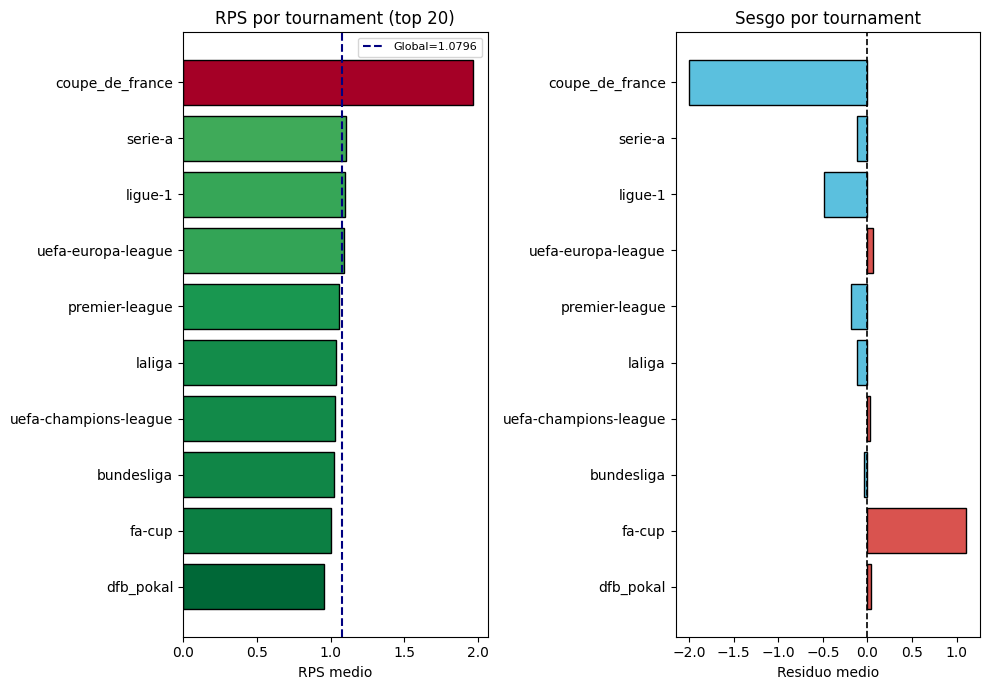


------------------------------------------------------------
  [5] Drift temporal - NGBoost_NegBin_Tuned | HOME
------------------------------------------------------------
  [SKIP] Ninguna columna temporal disponible: ['year_month', 'matchweek', 'date', 'match_date', 'season_week']

------------------------------------------------------------
  [alpha] Sobredispersion - NGBoost_NegBin_Tuned | HOME
------------------------------------------------------------
  alpha mean    : 0.1177
  alpha median  : 0.1178
  alpha p05/p95 : 0.0998 / 0.1404
  Var(Pearson)  : 0.9013   <- ~1 si NB ajusta bien
  Diagnostico   : dispersion razonable

------------------------------------------------------------
  [alpha] Sobredispersion - NGBoost_NegBin_Tuned | HOME
------------------------------------------------------------
  alpha mean    : 0.1177
  alpha median  : 0.1178
  alpha p05/p95 : 0.0998 / 0.1404
  Var(Pearson)  : 0.9013   <- ~1 si NB ajusta bien
  Diagnostico   : dispersion razonable


{'alpha_mean': 0.1176794882407675,
 'alpha_median': 0.11776474008290286,
 'pearson_var': 0.9013335363529368}

In [32]:
from src.error_analysis.distribution_error_analysis import DistributionErrorAnalyzer
META_VAL = ['match_datetime_utc', 'tournament']
meta_val_home = df_cleaned.loc[X_val_home.index, META_VAL].reset_index(drop=True)

analyzer_home = DistributionErrorAnalyzer(
    params     = results_nb["NGBoost"]["params"]["home"],   # ver nota abajo
    y_true     = y_val_home["home_total_corners"].values,
    family     = "negbin",
    meta       = meta_val_home,          # opcional: league, fecha, etc.
    component  = "home",
    model_name = "NGBoost_NegBin_Tuned",
    config     = cfg,
)

analyzer_home.run_all()
analyzer_home.summarize_dispersion()    # solo NegBin: contrasta alpha vs residuos de Pearson


  NGBoost_NegBin_Tuned [negbin] - AWAY | N=2,248
  RPS mean=1.11225  |  media predicha=4.2991

------------------------------------------------------------
  [1] Calibracion - NGBoost_NegBin_Tuned | AWAY
------------------------------------------------------------
  pred_bin   n  pred_mean  ytrue_mean  rps_mean
[1.5, 2.5)  31   2.214877    1.806452  0.714349
[2.5, 3.5) 455   3.116447    3.136264  1.106915
[3.5, 4.5) 895   4.023306    3.958659  1.136229
[4.5, 5.5) 611   4.954999    4.914894  1.136485
[5.5, 6.5) 213   5.888035    6.178404  1.058538
[6.5, 7.5)  40   6.777763    6.750000  0.923777
[7.5, 8.5)   2   7.674175   10.000000  0.317217
[8.5, 9.5)   1   8.650066    7.000000  0.178633


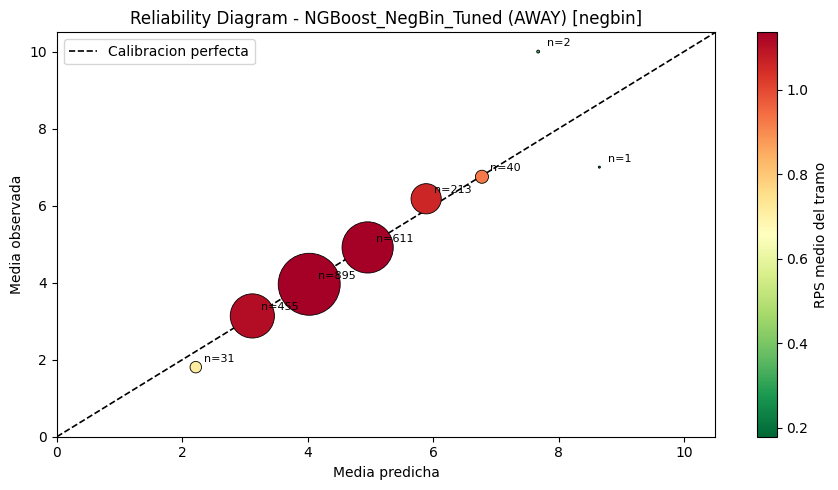


------------------------------------------------------------
  [2] Residuos por y_true - NGBoost_NegBin_Tuned | AWAY
------------------------------------------------------------
y_true   n  residual_mean  ci_low  ci_high
     0 112        -3.8026 -3.9499  -3.6375
     1 191        -2.7737 -2.8946  -2.6526
     2 312        -2.0019 -2.0927  -1.9117
     3 361        -1.1488 -1.2413  -1.0557
     4 354        -0.2814 -0.3728  -0.1869
     5 276         0.6555  0.5589   0.7558
    6+ 642         2.9461  2.8016   3.0975


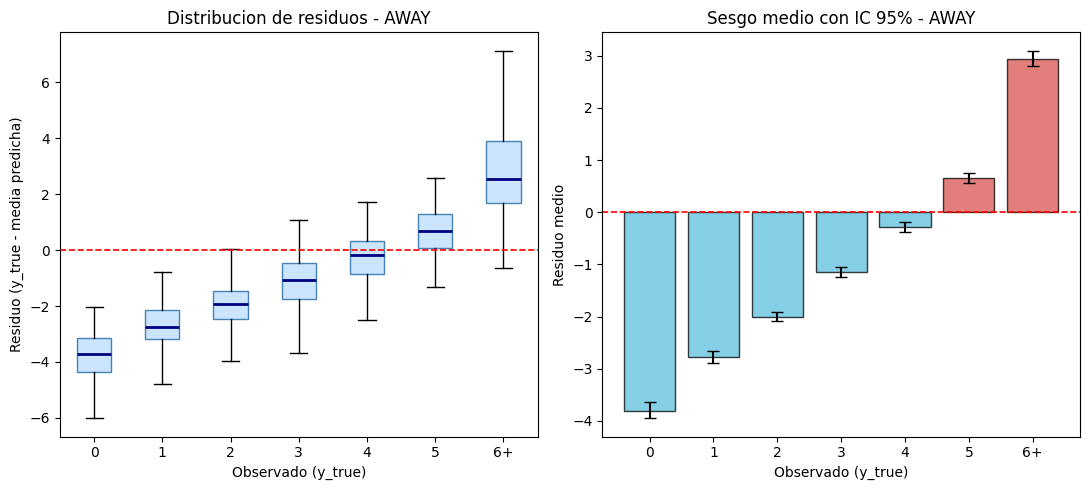


------------------------------------------------------------
  [3] Cola RPS > p95 - NGBoost_NegBin_Tuned | AWAY
------------------------------------------------------------
  Umbral RPS p95 : 2.37442
  En la cola          : 113 (5.0%)

grupo    n  rps_mean  ytrue_mean  pred_mean  residual_mean
 cola  113    2.8801      2.6283     4.3204        -1.6920
resto 2135    1.0187      4.3770     4.2979         0.0791


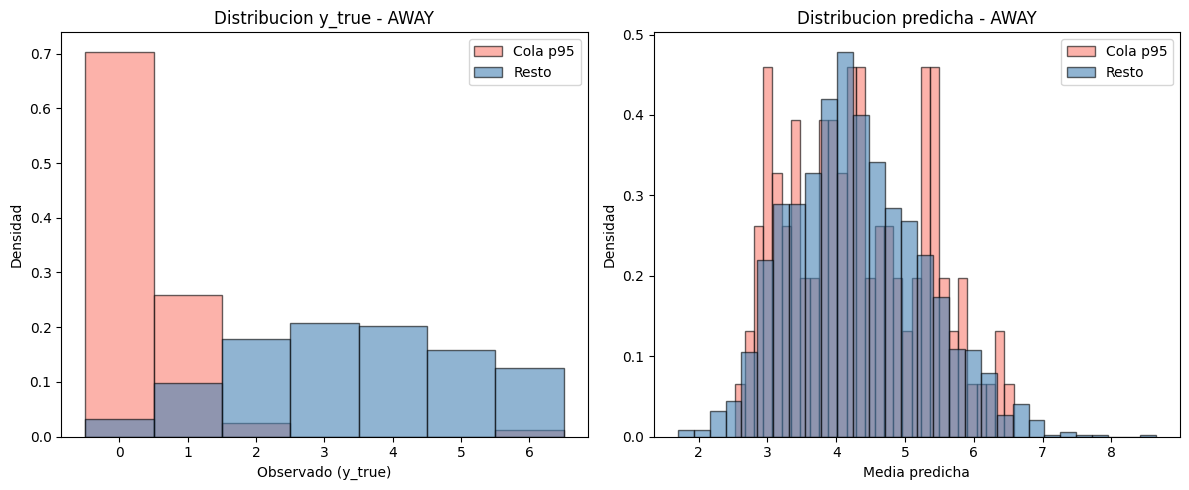


------------------------------------------------------------
  [4] Sesgo por 'tournament' - NGBoost_NegBin_Tuned | AWAY
------------------------------------------------------------
           tournament   n  rps_mean  residual_mean  ytrue_mean  pred_mean
      coupe_de_france  52  1.697877      -0.555518    3.423077   3.978595
            dfb_pokal  40  1.314985      -1.060702    3.325000   4.385702
   uefa-europa-league 169  1.146010       0.131682    4.295858   4.164176
              serie-a 395  1.133756      -0.058454    4.268354   4.326809
           bundesliga 293  1.125706      -0.041974    4.228669   4.270643
               fa-cup  22  1.108371      -0.829779    3.272727   4.102506
       premier-league 360  1.107505       0.200453    4.736111   4.535658
               laliga 409  1.061479      -0.104923    4.112469   4.217393
              ligue-1 310  1.060633       0.153983    4.422581   4.268597
uefa-champions-league 166  1.033580      -0.020595    4.295181   4.315776


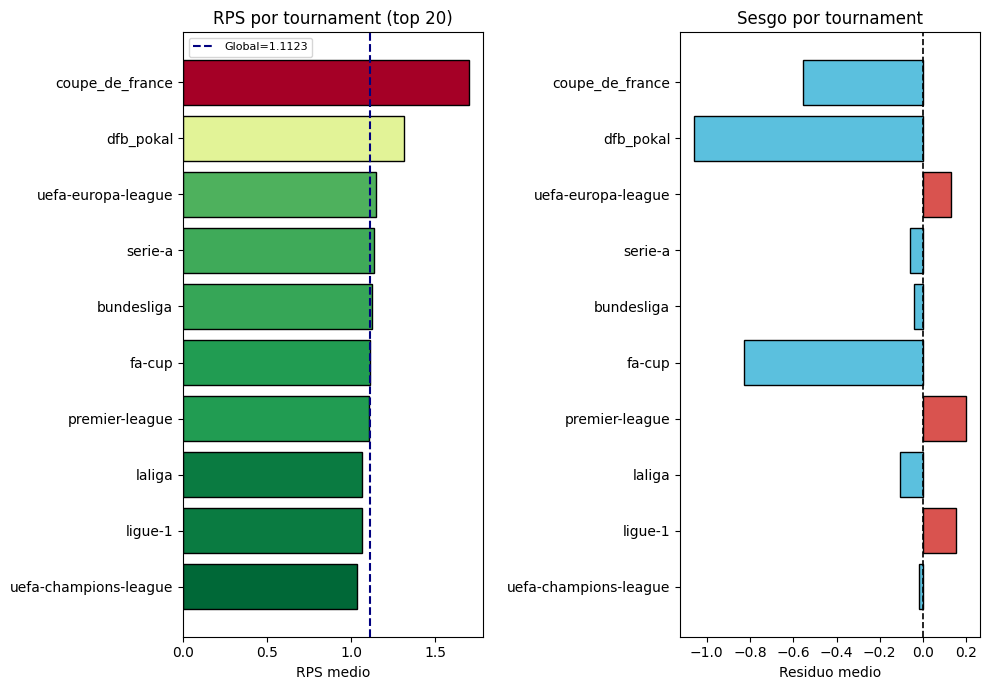


------------------------------------------------------------
  [5] Drift temporal - NGBoost_NegBin_Tuned | AWAY
------------------------------------------------------------
  [SKIP] Ninguna columna temporal disponible: ['year_month', 'matchweek', 'date', 'match_date', 'season_week']

------------------------------------------------------------
  [alpha] Sobredispersion - NGBoost_NegBin_Tuned | AWAY
------------------------------------------------------------
  alpha mean    : 0.1345
  alpha median  : 0.1330
  alpha p05/p95 : 0.1104 / 0.1638
  Var(Pearson)  : 0.9259   <- ~1 si NB ajusta bien
  Diagnostico   : dispersion razonable


In [33]:
META_VAL = ['match_datetime_utc', 'tournament']
meta_val_away = df_cleaned.loc[X_val_away.index, META_VAL].reset_index(drop=True)
analyzer_away = DistributionErrorAnalyzer(
    params     = results_nb["NGBoost"]["params"]["away"],   # ver nota abajo
    y_true     = y_val_away["away_total_corners"].values,
    family     = "negbin",
    meta       = meta_val_away,          
    component  = "away",
    model_name = "NGBoost_NegBin_Tuned",
    config     = cfg,
)
analyzer_away.run_all()


------------------------------------------------------------
  [6] Correlacion de error HOME vs AWAY | NGBoost_NegBin_Tuned
------------------------------------------------------------
  N observaciones    : 2,248
  Spearman rho (RPS) : 0.1094  p=2.0147e-07
  Spearman rho (res) : -0.1694  p=6.1004e-16
  Spearman rho (log) : -0.1715  p=2.6770e-16

  Interpretacion: Correlacion baja: los componentes fallan de forma independiente.


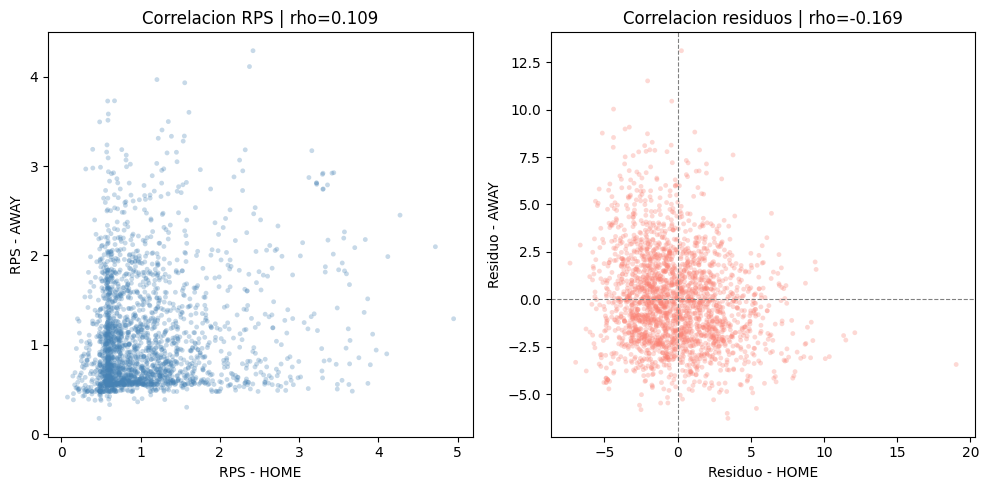

{'rho_rps': 0.1093636263492899,
 'p_rps': 2.0146600069968483e-07,
 'rho_residual': -0.16943064599074734,
 'p_residual': 6.100378317913894e-16,
 'rho_log': -0.17148971591055998,
 'p_log': 2.6770127789739347e-16}

In [34]:
DistributionErrorAnalyzer.correlation_between(analyzer_home, analyzer_away)

### Test Evaluation

In [37]:
X_te = {"home": X_test_home, "away": X_test_away}
y_te = {"home": y_test_home["home_total_corners"], "away": y_test_away["away_total_corners"]}

summary_test, results_test = evaluate_on_validation(
    cfg, X_tr, y_tr, X_va, y_va, feats,   # val sigue siendo el early stopping
    models      = ["NGBoost"],
    family      = "negbin",
    best_params = best_nb,
    X_eval      = X_te,                    # las metricas salen de aca
    y_eval      = y_te,
)

print(summary_test.to_string(index=False))

save_evaluation(results_test["NGBoost"], "test_ngboost_negbin_results", cfg,
                metadata={"split": "test", "label": "NGBoost_Poisson_Tuned"},
                metrics_dir=MODEL_DIR)

--- Entrenando NGBoost | home [negbin] ---
--- Entrenando NGBoost | away [negbin] ---

  FULL EVALUATION - NGBoost | negbin [negbin]

--------------------------------------------------
  RPS Report - NGBoost | negbin | home [negbin]
--------------------------------------------------
  N observaciones : 2527
  RPS mean        : 1.56463   <- principal
  RPS std         : 1.15301
  RPS median      : 1.14559
  RPS p95         : 3.85445   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - NGBoost | negbin | away [negbin]
--------------------------------------------------
  N observaciones : 2527
  RPS mean        : 1.37258   <- principal
  RPS std         : 1.04518
  RPS median      : 0.99850
  RPS p95         : 3.40058   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - NGBoost | negbin | home [negbin]
---------------------------------------

WindowsPath('c:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/models/corners/test_ngboost_negbin_results.json')

# Result

In [6]:
import numpy as np
import pandas as pd

from src.config.config import load_config
from src.evaluation.persistence import load_best_params, save_evaluation
from src.evaluation.model_persistence import build_bundle, save_bundle
from src.metrics.distribution_metrics import evaluate_from_config
from src.training.distribution_models import (
    train_and_predict, predict_params, clip_params,
)

cfg = load_config(CONFIG_PATH / "corners_config.yaml")
assert cfg.target.name == "corners", cfg.target.name

# ── 1. Cargar best params del YAML (el tuning ya corrio) ─────────────
best = {
    comp: load_best_params("NGBoost", cfg, family="negbin",
                            component=comp, params_only=True)
    for comp in ("home", "away")
}

# ── 2. Reentrenar con esos params ────────────────────────────────────
#     val = early stopping | test = metricas
trained = {}
for comp, X_tr, y_tr, X_va, y_va, feats in [
    ("home", X_train_home, y_train_home["home_total_corners"],
            X_val_home,   y_val_home["home_total_corners"],   X_train_home.columns.to_list()),
    ("away", X_train_away, y_train_away["away_total_corners"],
            X_val_away,   y_val_away["away_total_corners"],   X_train_away.columns.to_list()),
]:
    model, _, imputer = train_and_predict(
        "NGBoost", "negbin",
        X_tr[feats], y_tr, X_va[feats], y_va,
        params={**cfg.model_params("NGBoost"), **best[comp]},
        fit_params=cfg.fit_params("NGBoost"),
        guards=cfg.numeric_guards,
        return_imputer=True,
    )
    trained[comp] = {"model": model, "imputer": imputer, "features": feats}

# ── 3. Predecir sobre TEST y evaluar ─────────────────────────────────
params_test = {}
for comp, X_te in [("home", X_test_home), ("away", X_test_away)]:
    t = trained[comp]
    X_use = X_te[t["features"]]
    if t["imputer"] is not None:
        X_use = pd.DataFrame(t["imputer"].transform(X_use),
                            columns=X_use.columns, index=X_use.index)
    raw = predict_params(t["model"], X_use, "NGBoost", "negbin")
    params_test[comp] = clip_params(raw, "negbin", cfg.numeric_guards)

results = evaluate_from_config(
    y_true={"home": y_test_home["home_total_corners"].values,
            "away": y_test_away["away_total_corners"].values},
    params=params_test,
    config=cfg, family="negbin", label="NGBoost_negbin_Tuned",
)
save_evaluation(results, "ngboost_negbin_test_results", config=cfg,
                metadata={"split": "test"})

# ── 4. Guardar los bundles ───────────────────────────────────────────
for comp in ("home", "away"):
    t, p = trained[comp], params_test[comp]
    bundle = build_bundle(
        model=t["model"], model_name="NGBoost", family="negbin",
        component=comp, features=t["features"], config=cfg,
        imputer=t["imputer"],
        best_params=best[comp],
        metrics={
            "test_rps":     results["rps"][comp]["rps_mean"],
            "test_nll":     results["nll"][comp],
            "test_mu_mean": float(np.mean(p["mu"])),   # negbin -> mu
            "test_n":       int(results["rps"][comp]["n_samples"]),
        },
    )
    save_bundle(bundle, cfg)

 [METRICS] ngboost_negbin_test_results -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\corners\ngboost_negbin_test_results.json
 [MODEL] ngboost_negbin_home_12 -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\models\corners\ngboost_negbin_home_12.pkl  (1.1 MB)
 [MODEL] ngboost_negbin_away_13 -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\models\corners\ngboost_negbin_away_13.pkl  (2.4 MB)
